## Task #4. Photoelectric effect

Plot photoelectron stopping voltage vs frequency (or in-vacuum wavelength) of incident photons for various metals.

**Extension:** Create an animated app like the PhET demo.

In [1]:
import matplotlib.pyplot as plt
import numpy

E_CHARGE = 1.602 * 10**-19  # C (elementary charge)
H = 6.626 * 10**-34  # J s (Planck's constant)

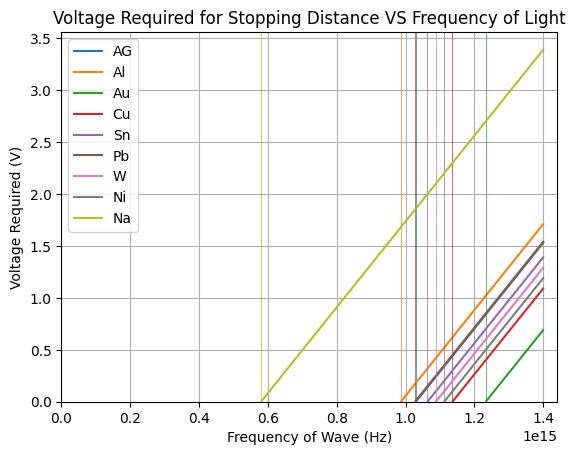

In [2]:
# Stopping Distance


def Calc(M, Freq):
    voltage = (H * Freq / E_CHARGE) - (M)
    return numpy.where(voltage > 0, voltage, numpy.nan)


def GraphCalc(MinFrequency, MaxFrequency, NumberOfFrequencyMeasurement):
    Freq = numpy.linspace(
        MinFrequency * 10**15, MaxFrequency * 10**15, NumberOfFrequencyMeasurement
    )
    WorkFunctions = [
        ("AG", 4.26),
        ("Al", 4.08),
        ("Au", 5.1),
        ("Cu", 4.7),
        ("Sn", 4.4),
        ("Pb", 4.25),
        ("W", 4.5),
        ("Ni", 4.6),
        ("Na", 2.4),
    ]  # metal -> work function M (eV)

    fig, ax = plt.subplots(1, 1)

    ax.grid(True, "both", "both")

    ax.set_xlabel("Frequency of Wave (Hz)")
    ax.set_ylabel("Voltage Required (V)")
    ax.set_title("Voltage Required for Stopping Distance VS Frequency of Light")

    for Name, M in WorkFunctions:
        Voltage = Calc(M, Freq)
        (Line,) = ax.plot(Freq, Voltage, label=Name)
        # Threshold frequency where the stopping voltage reaches zero: h*f = M.
        # Drawn in the same color as its diagonal so the two visibly match.
        ax.axvline(x=M * E_CHARGE / H, color=Line.get_color(), lw=0.5)

    ax.set_xlim(0)
    ax.set_ylim(0)

    ax.legend()
    plt.show()


GraphCalc(MinFrequency=0.3, MaxFrequency=1.4, NumberOfFrequencyMeasurement=500)